In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
import math

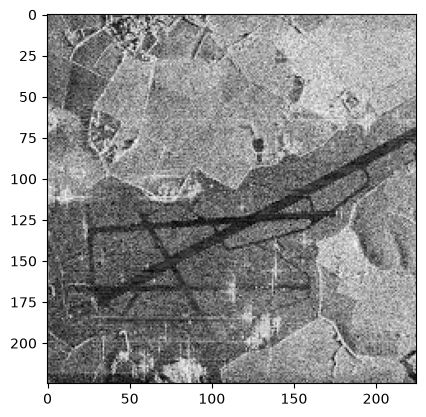

In [ ]:
# Наиболее протяженный участок через преобразование Хафа 
image = cv2.imread(r"C:\Users\arago\Desktop\leaning\home\sar_3.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")
plt.show()

image_gray_no_noise = cv2.GaussianBlur(image_gray, (5, 5), 0)

canny = cv2.Canny(image_gray_no_noise, 50, 150, apertureSize=3)
lines = cv2.HoughLines(canny, 1, np.pi / 180, 47)

ys, xs = np.where(canny > 0)
best = None
mx = 0
for i in range(len(lines)):
    rho = lines[i][0][0]
    theta = lines[i][0][1]
    cnt = 0
    for j in range(len(xs)):
        d = abs(xs[j]*math.cos(theta) + ys[j]*math.sin(theta) - rho)
        if d < 1.0:
            cnt += 1
    if cnt > mx:
        mx = cnt
        best = (rho, theta)

print("Best:", best)

rho, theta = best
a, b = math.cos(theta), math.sin(theta)
x0, y0 = a * rho, b * rho
pt1 = (int(x0 + 300*(-b)), int(y0 + 300*a))
pt2 = (int(x0 - 300*(-b)), int(y0 - 300*a))

image_2 = image.copy()   # определяем image_2
cv2.line(image_2, pt1, pt2, (0, 0, 255), 3, cv2.LINE_AA)

plt.imshow(cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB))
plt.show()

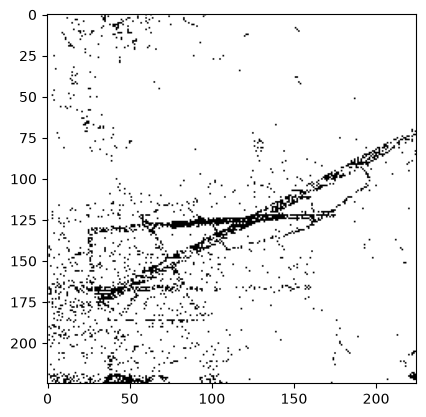

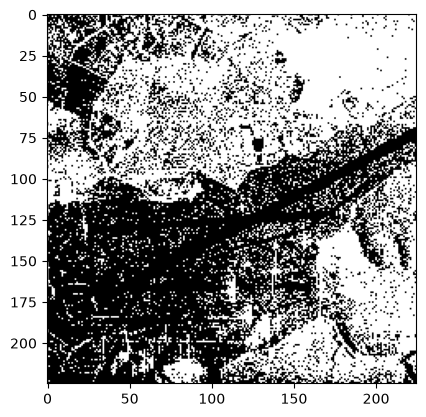

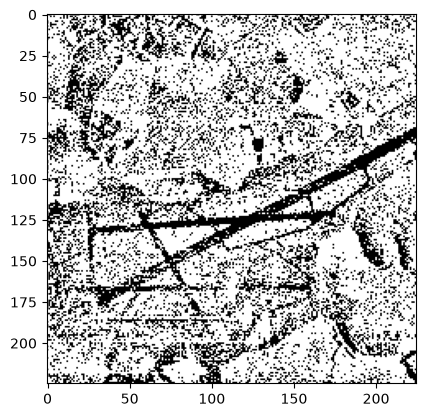

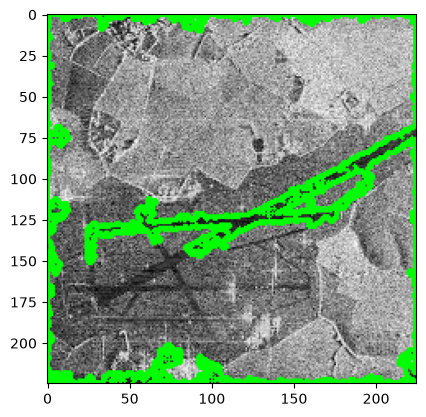

In [5]:
# Бинаризация, выделение дорожной полосы
# Точечная бинаризация
bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255
plt.imshow(bin_img, cmap="gray")
plt.show()

# Отсу
_, th2 = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(th2, cmap="gray")
plt.show()

# Адаптивная бинаризация
th3 = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                            cv2.THRESH_BINARY, 71, 21)
plt.imshow(th3, cmap="gray")
plt.show()

# Выделение участка дорожной полосы
road = cv2.bitwise_and(image, image, mask=th3)
plt.imshow(road)

contours, _ = cv2.findContours(th3, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
road_contours = copy.deepcopy(image)
cv2.drawContours(road_contours, contours, -1, (0, 255, 0), 2)
plt.imshow(road_contours)